In [2]:
import pandas as pd

In [3]:
train = pd.read_csv("../Data/Apart Deal.csv", dtype={6: str, 8: str})

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5002839 entries, 0 to 5002838
Data columns (total 9 columns):
 #   Column  Dtype  
---  ------  -----  
 0   지역코드    float64
 1   법정동     object 
 2   거래일     object 
 3   아파트     object 
 4   지번      object 
 5   전용면적    float64
 6   층       object 
 7   건축년도    float64
 8   거래금액    object 
dtypes: float64(3), object(6)
memory usage: 343.5+ MB


In [5]:
# 1. 한글 및 기타 문자 제거 (정규표현식 사용)
train['층'] = train['층'].astype(str).str.replace(r'[^\d]', '', regex=True)
train['거래금액'] = train['거래금액'].astype(str).str.replace(r'[^\d]', '', regex=True)

# 2. 숫자형으로 변환.
train['층'] = pd.to_numeric(train['층'], errors='coerce')
train['거래금액'] = pd.to_numeric(train['거래금액'], errors='coerce')

# 결과 확인
print(train[['층', '거래금액']].head())

      층   거래금액
0   8.0  26700
1   2.0  35500
2  11.0  36500
3   8.0  43000
4   7.0  38700


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5002839 entries, 0 to 5002838
Data columns (total 9 columns):
 #   Column  Dtype  
---  ------  -----  
 0   지역코드    float64
 1   법정동     object 
 2   거래일     object 
 3   아파트     object 
 4   지번      object 
 5   전용면적    float64
 6   층       float64
 7   건축년도    float64
 8   거래금액    int64  
dtypes: float64(4), int64(1), object(4)
memory usage: 343.5+ MB


In [7]:
# 파일 불러오기 (엑셀 파일)
address = pd.read_excel("../Data/법정동.xlsx", skiprows=1)

# "폐지여부" 열 제거
address = address.drop(columns=['폐지여부'], errors='ignore')

# 컬럼 이름 확인 (필요한 경우 이름 바꾸기)
address.columns = ['법정동코드', '법정동명']

# 인덱스 재설정
address = address.reset_index(drop=True)

# 결과 확인
print(address.head())

        법정동코드           법정동명
0  1100000000          서울특별시
1  1111000000      서울특별시 종로구
2  1111010100  서울특별시 종로구 청운동
3  1111010200  서울특별시 종로구 신교동
4  1111010300  서울특별시 종로구 궁정동


In [8]:
# 1. 법정동코드에서 시/군/구 주소 추출
address['지역코드'] = address['법정동코드'].astype(str).str[:5]
address_unique = address[['지역코드', '법정동명']].drop_duplicates(subset='지역코드')

# 2. Apart Deal 데이터 불러오기

train['지역코드'] = train['지역코드'].astype(str).str[:5]

# 3. merge로 시/군/구 주소 붙이기
train = train.merge(address_unique, on='지역코드', how='left')

# 4. 최종 주소 열 생성: 시군구 + 법정동
train['주소'] = train['법정동명']

# 5. 필요 없어진 열 제거 (선택)
train = train.drop(columns=['법정동명'])

# 결과 확인
print(train[['지역코드', '주소']].head())

    지역코드        주소
0  31110  울산광역시 중구
1  31110  울산광역시 중구
2  31110  울산광역시 중구
3  31110  울산광역시 중구
4  31110  울산광역시 중구


In [9]:
train.tail()

,지역코드,법정동,거래일,아파트,지번,전용면적,층,건축년도,거래금액,주소
5002834,50130,대정읍 하모리,2023-06-29 00:00:00,더그라벨아파트,1221-1,57.1300,6.0,2019.0,19500,제주특별자치도 서귀포시
5002835,50130,동홍동,2023-07-04 00:00:00,주공5차(동홍5차),1674,49.8700,2.0,1999.0,21700,제주특별자치도 서귀포시
5002836,50130,서홍동,2023-07-04 00:00:00,서홍반석타운,2004-1,45.3100,1.0,2000.0,9300,제주특별자치도 서귀포시
5002837,50130,중문동,2023-07-01 00:00:00,중문푸른마을,1789,51.8800,2.0,2003.0,25500,제주특별자치도 서귀포시
5002838,50130,중문동,2023-07-01 00:00:00,e편한세상중문,1726,84.9875,5.0,2021.0,52500,제주특별자치도 서귀포시


In [10]:
# 지역코드, 법정동, 법정동명(혹은 지역) 열 제거
train = train.drop(columns=['지역코드', '법정동'], errors='ignore')

# 결과 확인
print(train.columns)
train.head()

Index(['거래일', '아파트', '지번', '전용면적', '층', '건축년도', '거래금액', '주소'], dtype='object')


,거래일,아파트,지번,전용면적,층,건축년도,거래금액,주소
0,5/30/2020 0:00,남운학성타운,379,135.5800,8.0,1991.0,26700,울산광역시 중구
1,1/3/2020 0:00,남외푸르지오1차,506-1,101.6000,2.0,2006.0,35500,울산광역시 중구
2,1/3/2020 0:00,에일린의뜰,500,84.9920,11.0,2007.0,36500,울산광역시 중구
3,1/3/2020 0:00,남외푸르지오1차,506-1,118.7060,8.0,2006.0,43000,울산광역시 중구
4,1/4/2020 0:00,남외푸르지오2차,501-1,84.9636,7.0,2007.0,38700,울산광역시 중구


In [11]:
# 지번 열 제거
train = train.drop(columns=['지번'], errors='ignore')

# 결과 확인
print(train.columns)
train.head()

Index(['거래일', '아파트', '전용면적', '층', '건축년도', '거래금액', '주소'], dtype='object')


,거래일,아파트,전용면적,층,건축년도,거래금액,주소
0,5/30/2020 0:00,남운학성타운,135.5800,8.0,1991.0,26700,울산광역시 중구
1,1/3/2020 0:00,남외푸르지오1차,101.6000,2.0,2006.0,35500,울산광역시 중구
2,1/3/2020 0:00,에일린의뜰,84.9920,11.0,2007.0,36500,울산광역시 중구
3,1/3/2020 0:00,남외푸르지오1차,118.7060,8.0,2006.0,43000,울산광역시 중구
4,1/4/2020 0:00,남외푸르지오2차,84.9636,7.0,2007.0,38700,울산광역시 중구


In [114]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5002839 entries, 0 to 5002838
Data columns (total 7 columns):
 #   Column  Dtype  
---  ------  -----  
 0   거래일     object 
 1   아파트     object 
 2   전용면적    float64
 3   층       float64
 4   건축년도    float64
 5   거래금액    int64  
 6   주소      object 
dtypes: float64(3), int64(1), object(3)
memory usage: 267.2+ MB


In [12]:
train.주소.value_counts()

주소
경기도 화성시         112712
경기도 남양주시         86199
경기도 부천시          80877
경기도 김포시          67517
충청남도 천안시 서북구     64606
                 ...  
전라북도 장수군           286
경상북도 군위군           260
경상북도 영양군           134
경상북도 울릉군            36
전라남도 신안군             9
Name: count, Length: 249, dtype: int64

In [14]:
# 주소 기준 구 단위 거래량 상위 20개 출력
top_gu = train['주소'].value_counts().head(20)
print(top_gu)

주소
경기도 화성시         112712
경기도 남양주시         86199
경기도 부천시          80877
경기도 김포시          67517
충청남도 천안시 서북구     64606
경상남도 김해시         64605
경기도 용인시 수지구      64501
서울특별시 노원구        61866
경기도 시흥시          61801
경기도 용인시 기흥구      61387
대전광역시 서구         59370
대구광역시 달서구        57343
경상북도 구미시         57036
경기도 평택시          55236
강원도 원주시          53956
경상남도 양산시         53065
경기도 고양시 덕양구      51992
인천광역시 서구         51223
인천광역시 부평구        51116
경기도 고양시 일산서구     51077
Name: count, dtype: int64


In [ ]:
# # 문자열로 변환 후 슬래시(/) → 하이픈(-)으로 통일
# train['거래일'] = train['거래일'].astype(str).str.replace('/', '-', regex=False)

# # 다시 datetime으로 변환 (NaT가 생기면 강제 변환 방지)
# train['거래일'] = pd.to_datetime(train['거래일'], errors='coerce')

# # NaT 여부 확인
# print(train['거래일'].isnull().sum())

3956902


In [ ]:
# # pandas를 사용해 거래일을 datetime 형식으로 변환
# train['거래일'] = pd.to_datetime(train['거래일'], errors='coerce')


# # 건축년도 열을 datetime으로 변환 (1월 1일로 고정)

# train['건축년도'] = pd.to_datetime(train['건축년도'], format='%Y', errors='coerce')
# train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5002839 entries, 0 to 5002838
Data columns (total 7 columns):
 #   Column  Dtype         
---  ------  -----         
 0   거래일     datetime64[ns]
 1   아파트     object        
 2   전용면적    float64       
 3   층       float64       
 4   건축년도    float64       
 5   거래금액    int64         
 6   주소      object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(2)
memory usage: 267.2+ MB


In [88]:
train['거래일'].isnull().sum()

3956902

In [42]:
train.head()

,거래일,아파트,전용면적,층,건축년도,거래금액,주소
0,2020-05-30,남운학성타운,135.5800,8.0,1991.0,26700,울산광역시 중구
1,2020-01-03,남외푸르지오1차,101.6000,2.0,2006.0,35500,울산광역시 중구
2,2020-01-03,에일린의뜰,84.9920,11.0,2007.0,36500,울산광역시 중구
3,2020-01-03,남외푸르지오1차,118.7060,8.0,2006.0,43000,울산광역시 중구
4,2020-01-04,남외푸르지오2차,84.9636,7.0,2007.0,38700,울산광역시 중구


In [15]:
# 건축년도 열을 datetime으로 변환 (1월 1일로 고정)

train['건축년도'] = pd.to_datetime(train['건축년도'], format='%Y', errors='coerce')
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5002839 entries, 0 to 5002838
Data columns (total 7 columns):
 #   Column  Dtype         
---  ------  -----         
 0   거래일     object        
 1   아파트     object        
 2   전용면적    float64       
 3   층       float64       
 4   건축년도    datetime64[ns]
 5   거래금액    int64         
 6   주소      object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 267.2+ MB


In [16]:
train.head()

,거래일,아파트,전용면적,층,건축년도,거래금액,주소
0,5/30/2020 0:00,남운학성타운,135.5800,8.0,1991-01-01,26700,울산광역시 중구
1,1/3/2020 0:00,남외푸르지오1차,101.6000,2.0,2006-01-01,35500,울산광역시 중구
2,1/3/2020 0:00,에일린의뜰,84.9920,11.0,2007-01-01,36500,울산광역시 중구
3,1/3/2020 0:00,남외푸르지오1차,118.7060,8.0,2006-01-01,43000,울산광역시 중구
4,1/4/2020 0:00,남외푸르지오2차,84.9636,7.0,2007-01-01,38700,울산광역시 중구


In [45]:
train.describe()

,거래일,전용면적,층,건축년도,거래금액
count,1045937,5.002839e+06,5.002838e+06,5002763,5.002839e+06
mean,2019-06-11 01:25:34.336006656,7.533272e+01,1.029915e+01,2001-09-04 21:28:12.286682368,3.108044e+04
min,2018-01-01 00:00:00,9.260000e+00,1.000000e+00,1961-01-01 00:00:00,1.000000e+02
25%,2018-08-24 00:00:00,5.971000e+01,4.000000e+00,1995-01-01 00:00:00,1.490000e+04
50%,2019-07-31 00:00:00,7.671810e+01,8.000000e+00,2001-01-01 00:00:00,2.430000e+04
75%,2020-03-12 00:00:00,8.496000e+01,1.300000e+01,2009-01-01 00:00:00,3.800000e+04
max,2020-10-20 00:00:00,4.243200e+02,5.000000e+02,2023-01-01 00:00:00,1.450000e+06
std,NaN,2.607859e+01,1.329831e+01,NaN,2.864574e+04


In [19]:
nowon_df = train[train['주소'].str.contains("서울특별시 노원구", na=False)]
nowon_df.to_csv("../Data/노원구_아파트_거래.csv", index=False)

In [31]:
nowon_df = pd.read_csv("../Data/노원구_아파트_거래_통일.csv")

nowon_df.head()

,거래일,아파트,전용면적,층,건축년도,거래금액,주소
0,2018-01-02,동신아파트,59.99,4.0,1999-01-01,30950,서울특별시 노원구
1,2018-01-02,효성아파트,73.18,1.0,1995-01-01,38700,서울특별시 노원구
2,2018-01-02,효성아파트,73.18,4.0,1995-01-01,37300,서울특별시 노원구
3,2018-01-03,대주파크빌아파트,81.12,2.0,2003-01-01,36500,서울특별시 노원구
4,2018-01-04,시영2단지(라이프)아파트,34.44,7.0,1994-01-01,19300,서울특별시 노원구


In [32]:
print(nowon_df['거래일'].isna().sum())  # 변환 실패한 행 수
print(nowon_df[nowon_df['거래일'].isna()])  # 어떤 데이터인지 직접 보기

0
Empty DataFrame
Columns: [거래일, 아파트, 전용면적, 층, 건축년도, 거래금액, 주소]
Index: []


In [33]:
# 주소 컬럼 제거
nowon_df = nowon_df.drop(columns=['주소'])

# 결과 확인
nowon_df.head()

,거래일,아파트,전용면적,층,건축년도,거래금액
0,2018-01-02,동신아파트,59.99,4.0,1999-01-01,30950
1,2018-01-02,효성아파트,73.18,1.0,1995-01-01,38700
2,2018-01-02,효성아파트,73.18,4.0,1995-01-01,37300
3,2018-01-03,대주파크빌아파트,81.12,2.0,2003-01-01,36500
4,2018-01-04,시영2단지(라이프)아파트,34.44,7.0,1994-01-01,19300


In [34]:
nowon_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61866 entries, 0 to 61865
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   거래일     61866 non-null  object 
 1   아파트     61866 non-null  object 
 2   전용면적    61866 non-null  float64
 3   층       61866 non-null  float64
 4   건축년도    61866 non-null  object 
 5   거래금액    61866 non-null  int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 2.8+ MB


In [35]:
# 숫자형 열들의 상관계수 행렬 출력
corr_matrix = nowon_df.corr(numeric_only=True)

print(corr_matrix)

          전용면적         층      거래금액
전용면적  1.000000  0.080495  0.608158
층     0.080495  1.000000  0.092628
거래금액  0.608158  0.092628  1.000000


In [36]:
nowon_df.head()

,거래일,아파트,전용면적,층,건축년도,거래금액
0,2018-01-02,동신아파트,59.99,4.0,1999-01-01,30950
1,2018-01-02,효성아파트,73.18,1.0,1995-01-01,38700
2,2018-01-02,효성아파트,73.18,4.0,1995-01-01,37300
3,2018-01-03,대주파크빌아파트,81.12,2.0,2003-01-01,36500
4,2018-01-04,시영2단지(라이프)아파트,34.44,7.0,1994-01-01,19300


In [37]:
# pandas를 사용해 거래일을 datetime 형식으로 변환
nowon_df['거래일'] = pd.to_datetime(nowon_df['거래일'], errors='coerce')


# 건축년도 열을 datetime으로 변환 (1월 1일로 고정)

nowon_df['건축년도'] = pd.to_datetime(nowon_df['건축년도'].astype(str) + '-01-01', errors='coerce')
nowon_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61866 entries, 0 to 61865
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype                    
---  ------  --------------  -----                    
 0   거래일     61866 non-null  datetime64[ns]           
 1   아파트     61866 non-null  object                   
 2   전용면적    61866 non-null  float64                  
 3   층       61866 non-null  float64                  
 4   건축년도    61866 non-null  datetime64[ns, UTC-01:00]
 5   거래금액    61866 non-null  int64                    
dtypes: datetime64[ns, UTC-01:00](1), datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 2.8+ MB


/var/folders/y7/sgfgsqsd6mvdck9dy84gxqb40000gn/T/ipykernel_933/1108198971.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  nowon_df['건축년도'] = pd.to_datetime(nowon_df['건축년도'].astype(str) + '-01-01', errors='coerce')


In [38]:
# 건물연차 컬럼 생성
nowon_df['건물연차'] = nowon_df['거래일'].dt.year - nowon_df['건축년도'].dt.year


In [39]:
corr_matrix = nowon_df.corr(numeric_only=True)
print(corr_matrix)

          전용면적         층      거래금액      건물연차
전용면적  1.000000  0.080495  0.608158 -0.318186
층     0.080495  1.000000  0.092628 -0.140802
거래금액  0.608158  0.092628  1.000000  0.011203
건물연차 -0.318186 -0.140802  0.011203  1.000000


In [40]:
nowon_df['거래일'].dtype

dtype('<M8[ns]')

In [41]:
# 거래일, 건축년도 컬럼 제거
nowon_df = nowon_df.drop(columns=['거래일','건축년도'])

# 결과 확인
nowon_df.head()

,아파트,전용면적,층,거래금액,건물연차
0,동신아파트,59.99,4.0,30950,19
1,효성아파트,73.18,1.0,38700,23
2,효성아파트,73.18,4.0,37300,23
3,대주파크빌아파트,81.12,2.0,36500,15
4,시영2단지(라이프)아파트,34.44,7.0,19300,24


In [42]:
nowon_df.isnull().sum()

아파트     0
전용면적    0
층       0
거래금액    0
건물연차    0
dtype: int64

In [ ]:
# 선형회귀
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


X = nowon_df[['전용면적', '층', '건물연차']]
y = nowon_df['거래금액']

# 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 이후 선형 회귀 학습
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [44]:

# 예측 및 평가
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# 결과 출력
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("회귀 계수:", model.coef_)
print("절편:", model.intercept_)

MAE: 10164.855795159148
RMSE: 13927.821798904872
R²: 0.41330423604735667
회귀 계수: [12294.56626418  1288.84121637  4289.9266291 ]
절편: 39358.468498364964


In [48]:
# 랜덤포레스트
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 정의
X = nowon_df[['전용면적', '층', '건물연차']]
y = nowon_df['거래금액']

# 표준화 (랜덤포레스트는 꼭 필요하지 않지만 비교 위해 동일 처리)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, random_state=42)

# 랜덤포레스트 회귀 모델 학습
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 예측 및 평가
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# 결과 출력
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 4025.155483527751
RMSE: 6752.8484787589
R²: 0.8620821241667185


/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52789 (\N{HANGUL SYLLABLE CEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_f

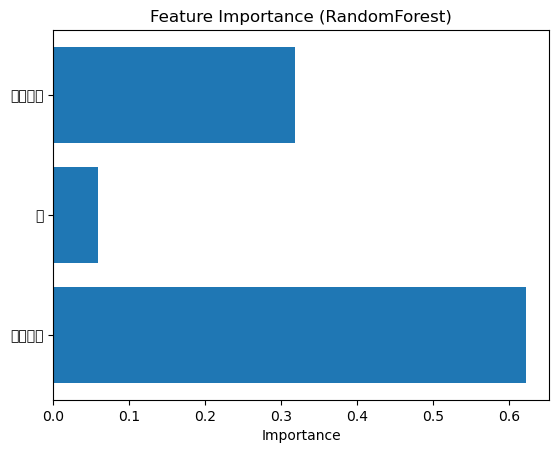

In [49]:
# 변수 중요도 확인

import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance (RandomForest)")
plt.xlabel("Importance")
plt.show()

In [50]:
# XGBoost

from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# X, y 정의
X = nowon_df[['전용면적', '층', '건물연차']]
y = nowon_df['거래금액']

# 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 분할
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, random_state=42)

# XGBoost 모델 학습
model = XGBRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 예측 및 평가
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("XGBoost Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

XGBoost Results
MAE: 5100.837207656321
RMSE: 8035.400442352042
R²: 0.8047182559967041
